# 1. Import Necessary Libraries
Import `torch` for modeling, `terratorch` for the backbone, `h5py` for data, and `matplotlib` with `seaborn` for visualization.

In [1]:
import torch
import torch.nn.functional as F
import h5py
import rasterio
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from terratorch import BACKBONE_REGISTRY
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/shared/home/elucas/scratch/terra-sat-drift/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


# 2. Load Model
Initialize the pre-trained `terramind_v1_tiny` backbone. We specify the 7 bands (RGB, RedEdge, NIR) used for domain alignment.

In [ ]:
backbone_name = "terramind_v1_tiny"
encoder = BACKBONE_REGISTRY.build(
    backbone_name,
    pretrained=True,
    modalities=["S2L1C"],
    bands={"S2L1C": {"B02": 0, "B03": 1, "B04": 2, "B05": 3, "B08": 4, "B06": 5, "B07": 6}}
).to(device).eval()

# 3. Prepare Input Pair
Extract a pair of Sentinel-2B (Source) and Simulated-S-2 (Target) images from the processed dataset.

In [ ]:
import os
from glob import glob

source_root = "/shared/home/elucas/datasets/sen1floods11_simulated/v1.1/data/flood_events/HandLabeled/S2Hand/"
target_root = "/shared/home/elucas/datasets/sen1floods11_simulated_alt_v1/v1.1/data/flood_events/HandLabeled/S2Hand/"

TARGET_SIZE = (1088, 1088)

# Find common files
source_files = sorted(glob(os.path.join(source_root, "*.tif")))
source_filenames = {os.path.basename(f) for f in source_files}

common_pairs = []
for s_path in source_files:
    fname = os.path.basename(s_path)
    t_path = os.path.join(target_root, f"simulated_L1C_{fname}")
    # t_path = os.path.join(target_root, fname)
    if os.path.exists(t_path):
        common_pairs.append((s_path, t_path))

print(f"Found {len(common_pairs)} common image pairs.")

def load_and_preprocess(s_path, t_path):
    # Load Source (S2B)
    with rasterio.open(s_path) as src:
        # # Read bands B02, B03, B04, B05, B06, B07, B08 (Indices 2-8)
        s_img = src.read([2, 3, 4, 5, 6, 7, 8])
        # # Note: Depending on file size, we might want to resize source too if it's not 1088x1088
        # # But usually S2Hand tiles are 512x512. Terratorch usually handles variable sizes or expects fixed.
        # # Let's resize both to 1088x1088 for consistency in the batch.
        s_img = s_img.transpose(1, 2, 0)
        s_img = cv2.resize(s_img, TARGET_SIZE, interpolation=cv2.INTER_LINEAR)
        s_img = s_img.transpose(2, 0, 1)
        # Read the 7 bands excluding the PAN band at index 3
        # s_img = src.read([1, 2, 3, 5, 6, 7, 8])
        # s_img = s_img.transpose(1, 2, 0)
        # s_img = cv2.resize(s_img, TARGET_SIZE, interpolation=cv2.INTER_LINEAR)
        # s_img = s_img.transpose(2, 0, 1)
        
    # Load Target (Simulated)
    with rasterio.open(t_path) as src:
        # Read the 7 bands excluding the PAN band at index 3
        t_img = src.read([1, 2, 3, 5, 6, 7, 8])
        t_img = t_img.transpose(1, 2, 0)
        t_img = cv2.resize(t_img, TARGET_SIZE, interpolation=cv2.INTER_LINEAR)
        t_img = t_img.transpose(2, 0, 1)
        
    return torch.from_numpy(s_img).float(), torch.from_numpy(t_img).float()

# Load a batch of 4 samples
batch_size = 4
batch_source = []
batch_target = []

for i in range(batch_size):
    s_path, t_path = common_pairs[i]
    s_img, t_img = load_and_preprocess(s_path, t_path)
    batch_source.append(s_img)
    batch_target.append(t_img)

source_img = torch.stack(batch_source).to(device)
target_img = torch.stack(batch_target).to(device)

print(f"Batch Source shape: {source_img.shape}")
print(f"Batch Target shape: {target_img.shape}")

Found 430 common image pairs.
Batch Source shape: torch.Size([4, 7, 1088, 1088])
Batch Target shape: torch.Size([4, 7, 1088, 1088])


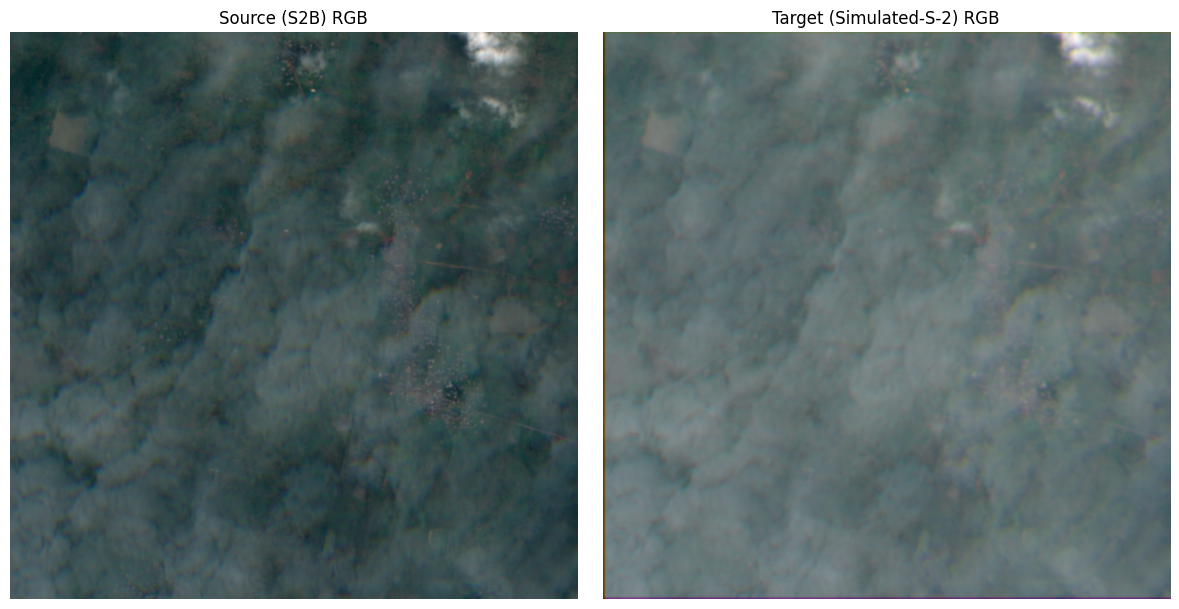

In [7]:
import numpy as np

def normalize(img):
    # Standard normalization for Sentinel-2B
    img = img.cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return img.transpose(1, 2, 0)

def normalize_simulated(img):
    # Simple min-max normalization for simulated data
    img = img.cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return img.transpose(1, 2, 0)

plt.figure(figsize=(12, 6))

# Sentinel-2B RGB (Indices 2, 1, 0 correspond to B04, B03, B02)
plt.subplot(1, 2, 1)
plt.imshow(normalize(source_img[0, [2, 1, 0]]))
plt.title("Source (S2B) RGB")
plt.axis('off')

# PhiSat-2 RGB (Indices 3, 2, 1 correspond to R, G, B in real/images)
plt.subplot(1, 2, 2)
# We apply the specific phisat normalization
# Note: target_img only contains first 7 bands (0 to 6)
# real/images bands: 0:PAN, 1:B, 2:G, 3:R, 4:RE1, 5:RE2, 6:RE3, 7:NIR
# So index 3, 2, 1 are R, G, B
plt.imshow(normalize_simulated(target_img[0, [2, 1, 0]]))
plt.title("Target (Simulated-S-2) RGB")
plt.axis('off')

plt.tight_layout()
plt.show()

# 4. Extract Embedding Layer Tensors
Pass the images through the encoder and extract the feature vectors from the final transformer layer outputs.

In [8]:
with torch.no_grad():
    # Encoder returns a list of layer outputs; we take the last one [-1]
    # source_img and target_img are now batches (B, C, H, W)
    source_seq = encoder(source_img)[-1]
    target_seq = encoder(target_img)[-1]

    # Global Average Pooling per image in the batch
    # Resulting shape: (B, D) where D is embedding dimension
    source_emb = source_seq.mean(dim=1)
    target_emb = target_seq.mean(dim=1)

print(f"Sequence shape: {source_seq.shape}")
print(f"Aggregated embedding batch shape: {source_emb.shape}")

Sequence shape: torch.Size([4, 4624, 192])
Aggregated embedding batch shape: torch.Size([4, 192])


# 5. Calculate Cosine Similarity
Compute the similarity between the two embedding vectors using the formula: $$S_C(A, B) = \frac{A \cdot B}{\|A\| \|B\|}$$

In [11]:
# Compute batch-wise cosine similarity
# source_emb and target_emb are (B, D)
similarities = F.cosine_similarity(source_emb, target_emb)
print(f"Mean Cosine Similarity for the batch: {similarities.mean().item():.4f}")
print(f"Individual similarities: {similarities.cpu().numpy()}")

Mean Cosine Similarity for the batch: 0.1372
Individual similarities: [0.13282147 0.16591388 0.11319933 0.13671075]


# 6. Plot Embedding Visualizations
Visualize the embedding feature maps for both domains. We plot the token feature matrix (where rows are tokens/patches and columns are feature dimensions).

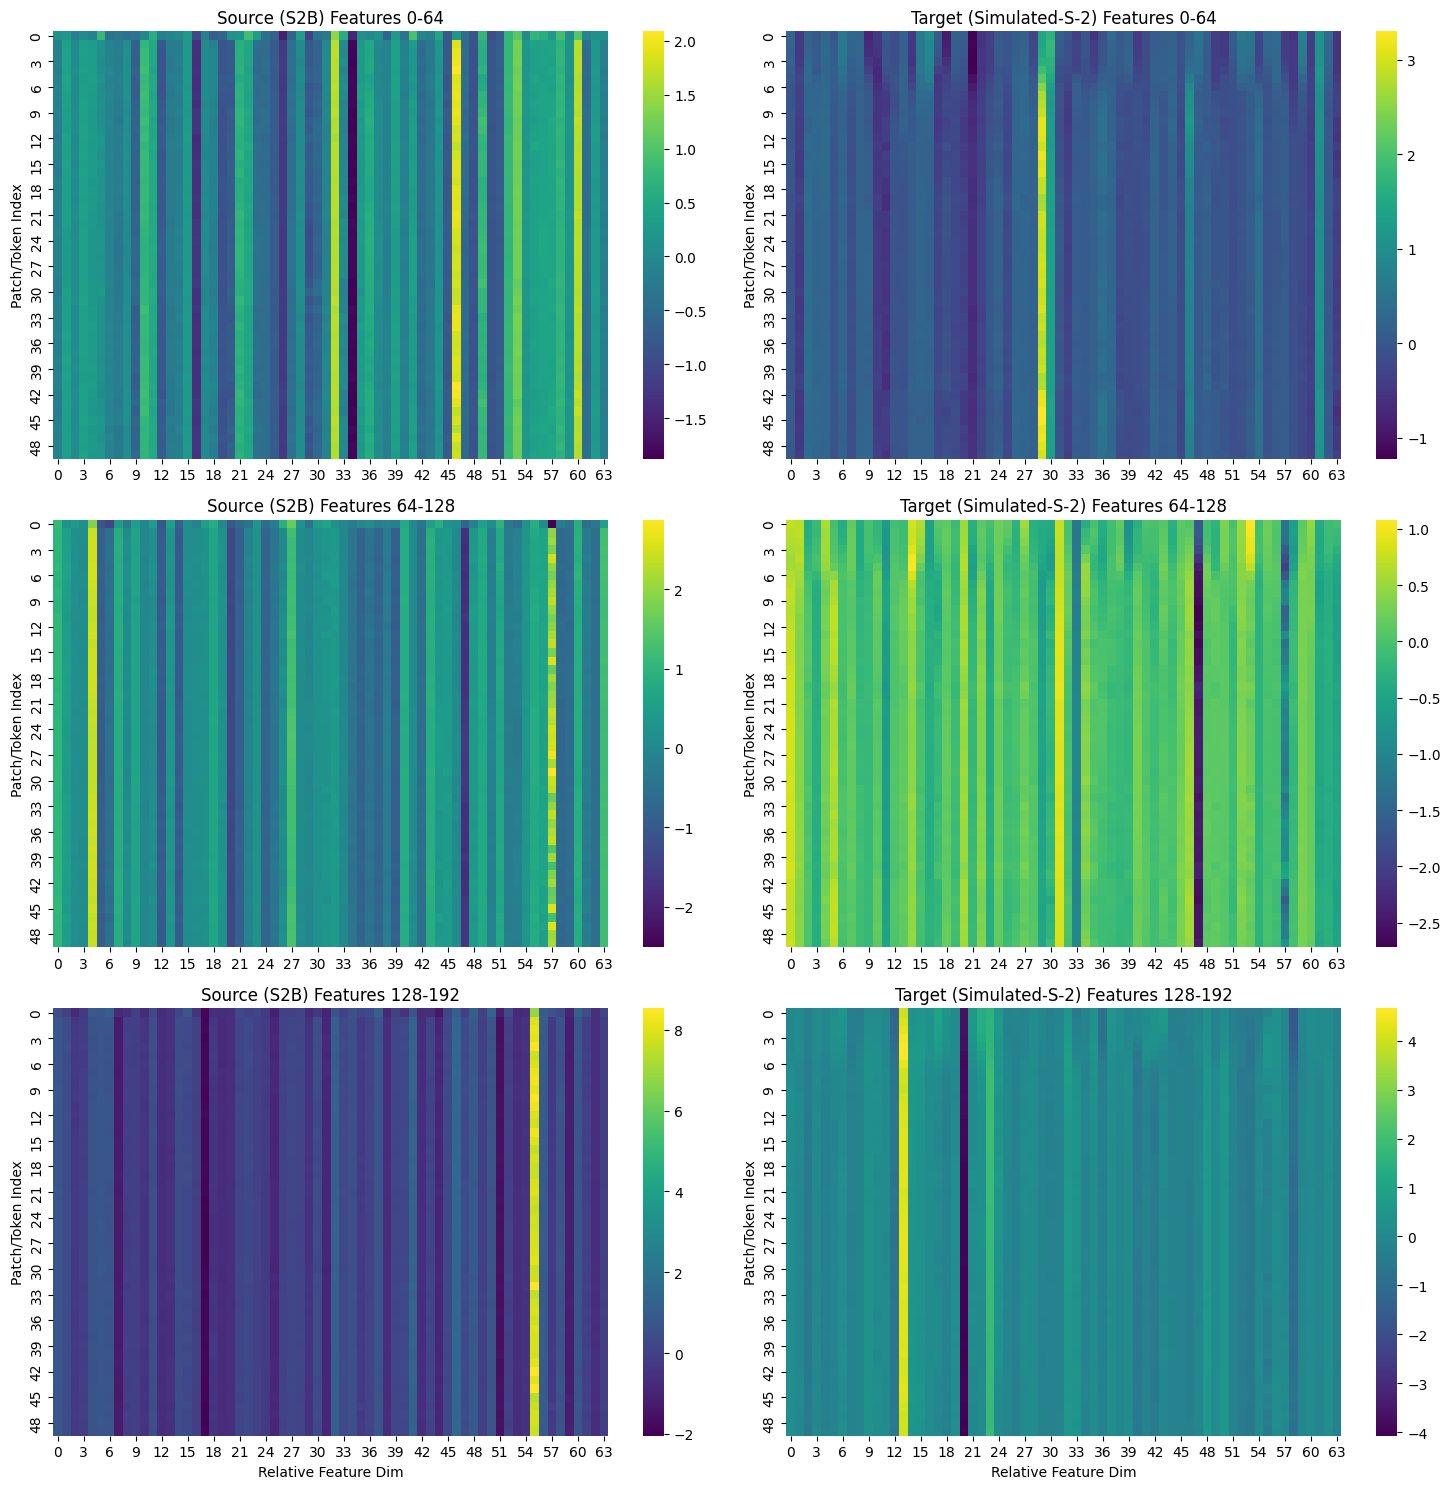

In [33]:
# Get sequence as numpy for plotting (taking first 50 tokens)
# We will split the 192 feature dimensions into 3 groups of 64 for better visibility
n_tokens = 50
n_features = source_seq.shape[2] # 192
n_groups = 3
feat_per_group = n_features // n_groups

source_np = source_seq[0, :n_tokens, :].cpu().numpy()
target_np = target_seq[0, :n_tokens, :].cpu().numpy()

fig, axes = plt.subplots(n_groups, 2, figsize=(15, 5 * n_groups))

for group in range(n_groups):
    start_feat = group * feat_per_group
    end_feat = (group + 1) * feat_per_group
    
    # Source
    sns.heatmap(source_np[:, start_feat:end_feat], ax=axes[group, 0], cmap="viridis", cbar=True)
    axes[group, 0].set_title(f"Source (S2B) Features {start_feat}-{end_feat}")
    axes[group, 0].set_ylabel("Patch/Token Index")
    if group == n_groups - 1:
        axes[group, 0].set_xlabel("Relative Feature Dim")

    # Target
    sns.heatmap(target_np[:, start_feat:end_feat], ax=axes[group, 1], cmap="viridis", cbar=True)
    axes[group, 1].set_title(f"Target (Simulated-S-2) Features {start_feat}-{end_feat}")
    axes[group, 1].set_ylabel("Patch/Token Index")
    if group == n_groups - 1:
        axes[group, 1].set_xlabel("Relative Feature Dim")

plt.tight_layout()
plt.show()

# 7. Cosine Similarity per Layer
Evaluate how the similarity between domains evolves through the transformer layers.

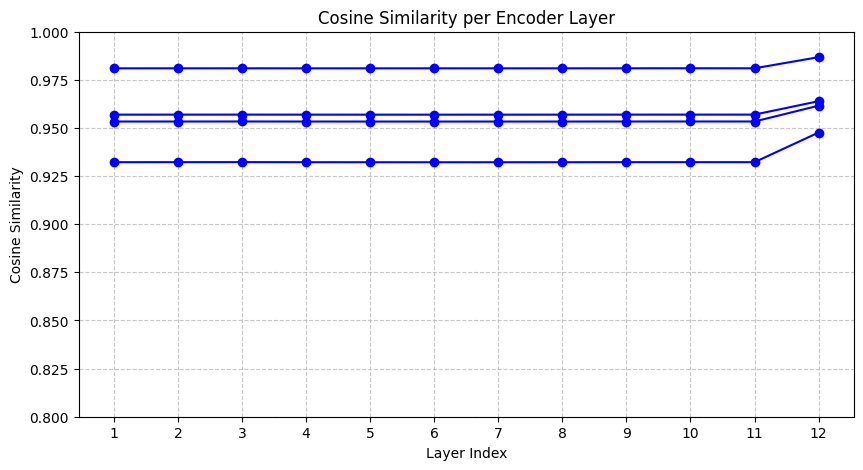

In [61]:
with torch.no_grad():
    source_layers = encoder(source_img)
    target_layers = encoder(target_img)
    
    similarities = []
    for s_feat, t_feat in zip(source_layers, target_layers):
        # Mean pooling per layer
        s_emb = s_feat.mean(dim=1)
        t_emb = t_feat.mean(dim=1)
        sim = F.cosine_similarity(s_emb, t_emb)
        similarities.append(sim.cpu().numpy())

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(similarities) + 1), similarities, marker='o', linestyle='-', color='b')
plt.title("Cosine Similarity per Encoder Layer")
plt.xlabel("Layer Index")
plt.ylabel("Cosine Similarity")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(1, len(similarities) + 1))
plt.ylim(0.8, 1.0) # Adjust based on expected range
plt.show()

# 8. Average Cosine Similarity per Layer (100 Samples)
Analyze the domain similarity across 100 samples to get a statistically significant trend.

In [ ]:
import numpy as np

# We use the list of common_pairs discovered in Step 3
num_samples = min(100, len(common_pairs)) 
all_layer_similarities = []

print(f"Processing {num_samples} samples...")

for i in range(num_samples):
    s_path, t_path = common_pairs[i]
    s_img, t_img = load_and_preprocess(s_path, t_path)
    s_img = s_img.unsqueeze(0).to(device)
    t_img = t_img.unsqueeze(0).to(device)
    
    with torch.no_grad():
        s_layers = encoder(s_img)
        t_layers = encoder(t_img)
        
        sample_sims = []
        for s_feats, t_feats in zip(s_layers, t_layers):
            # Mean pool sequence to get global representation
            s_pooled = s_feats.mean(dim=1)
            t_pooled = t_feats.mean(dim=1)
            # Compute cosine similarity
            sim = F.cosine_similarity(s_pooled, t_pooled)
            sample_sims.append(sim.item())
        
        all_layer_similarities.append(sample_sims)

# Convert to numpy for easy averaging
all_layer_similarities = np.array(all_layer_similarities)
mean_similarities = all_layer_similarities.mean(axis=0)
std_similarities = all_layer_similarities.std(axis=0)

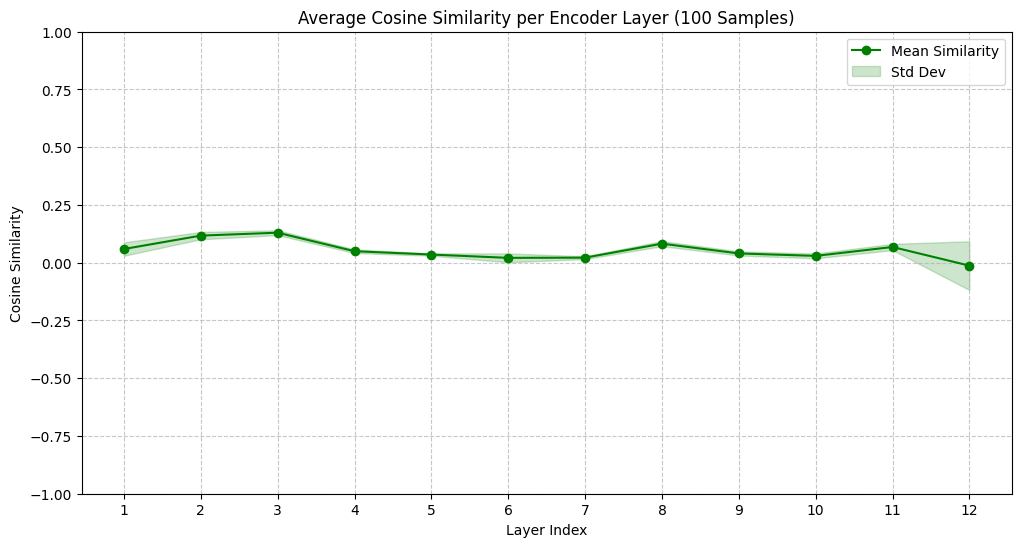

In [36]:

# Plotting
plt.figure(figsize=(12, 6))
layers = range(1, len(mean_similarities) + 1)
plt.plot(layers, mean_similarities, marker='o', linestyle='-', color='g', label='Mean Similarity')
plt.fill_between(layers, mean_similarities - std_similarities, mean_similarities + std_similarities, alpha=0.2, color='g', label='Std Dev')

plt.title(f"Average Cosine Similarity per Encoder Layer ({num_samples} Samples)")
plt.xlabel("Layer Index")
plt.ylabel("Cosine Similarity")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(layers)
plt.ylim(-1.0, 1.0)
plt.legend()
plt.show()

# 9. t-SNE Visualization of Domain Embeddings
Reduce the dimensionality of the aggregated embeddings to 2D using t-SNE to observe the distribution and overlap between Sentinel-2B (Source) and Simulated-S-2 (Target).

Extracting embeddings for 100 samples...


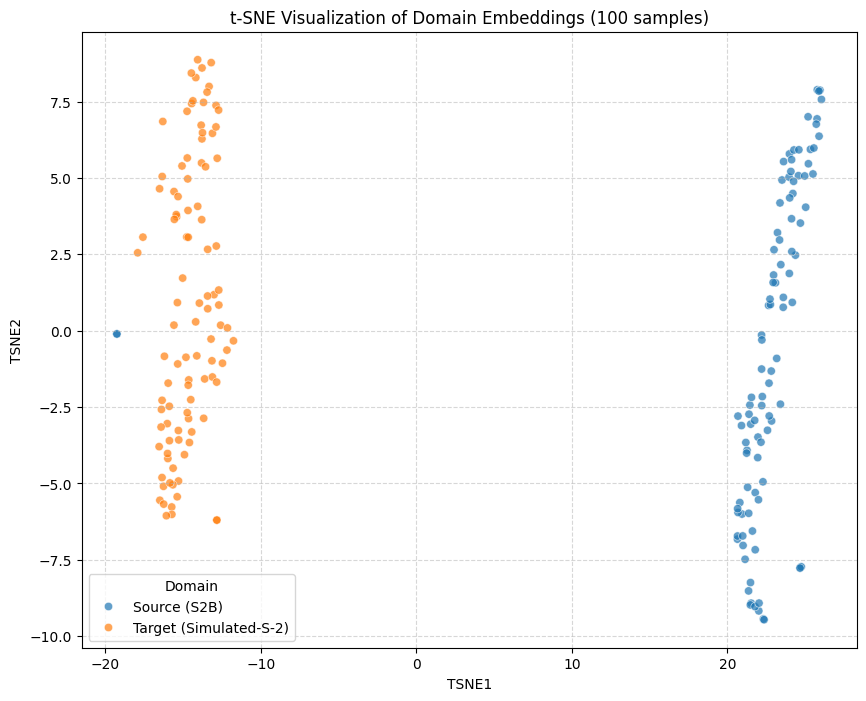

In [12]:
from sklearn.manifold import TSNE
import pandas as pd

tsne_samples = min(100, len(common_pairs))

source_embs_list = []
target_embs_list = []

print(f"Extracting embeddings for {tsne_samples} samples...")

for i in range(tsne_samples):
    s_path, t_path = common_pairs[i]
    s_img, t_img = load_and_preprocess(s_path, t_path)
    s_img = s_img.unsqueeze(0).to(device)
    t_img = t_img.unsqueeze(0).to(device)
    
    with torch.no_grad():
        # Get last layer features
        s_out = encoder(s_img)[-1].mean(dim=1).cpu().numpy()
        t_out = encoder(t_img)[-1].mean(dim=1).cpu().numpy()
        
        source_embs_list.append(s_out)
        target_embs_list.append(t_out)

# Prepare data for t-SNE
X = np.vstack([np.vstack(source_embs_list), np.vstack(target_embs_list)])
y = ["Source (S2B)"] * tsne_samples + ["Target (Simulated-S-2)"] * tsne_samples

# Run t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_embedded = tsne.fit_transform(X)

# Plotting
df_tsne = pd.DataFrame(X_embedded, columns=['TSNE1', 'TSNE2'])
df_tsne['Domain'] = y

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_tsne, x='TSNE1', y='TSNE2', hue='Domain', alpha=0.7)
plt.title(f"t-SNE Visualization of Domain Embeddings ({tsne_samples} samples)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 10. MMD Score Calculation & Visualization
Define the MMD loss and calculate the discrepancy between source and target feature distributions for a large sample set.

Calculating MMD for 430 samples...


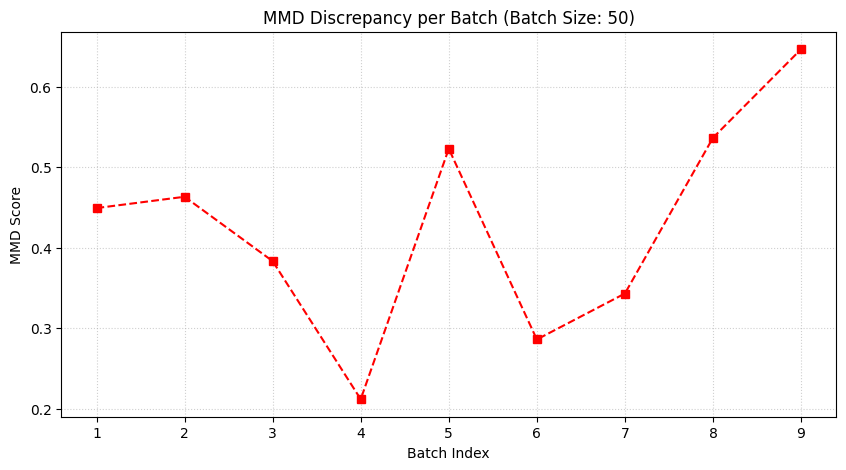

Mean MMD score across 430 samples: 0.426873


In [ ]:
import torch.nn as nn

class RBFKernel(nn.Module):
    def __init__(self, sigmas=[1.0, 2.0, 4.0, 8.0, 16.0]):
        super(RBFKernel, self).__init__()
        self.sigmas = torch.tensor(sigmas).to(device)

    def forward(self, X, Y):
        X_expanded = X.unsqueeze(1)
        Y_expanded = Y.unsqueeze(0)
        dist_squared = torch.sum((X_expanded - Y_expanded) ** 2, dim=2)
        kernel_val = torch.zeros_like(dist_squared)
        for sigma in self.sigmas:
            gamma = 1.0 / (2.0 * sigma ** 2)
            kernel_val += torch.exp(-gamma * dist_squared)
        return kernel_val / len(self.sigmas)

class MMDLoss(nn.Module):
    def __init__(self, sigmas=[1.0, 2.0, 4.0, 8.0, 16.0]):
        super(MMDLoss, self).__init__()
        self.kernel = RBFKernel(sigmas)

    def forward(self, X, Y):
        k_xx = self.kernel(X, X)
        k_yy = self.kernel(Y, Y)
        k_xy = self.kernel(X, Y)
        n, m = X.size(0), Y.size(0)
        mmd_squared = k_xx.sum() / (n * n) + k_yy.sum() / (m * m) - 2.0 * k_xy.sum() / (n * m)
        return torch.relu(mmd_squared)

# Parameters
mmd_total_samples = min(200, len(common_pairs))
batch_size = 50
mmd_criterion = MMDLoss().to(device)
mmd_results = []

print(f"Calculating MMD for {mmd_total_samples} samples...")

# Collect features in batches
for i in range(0, mmd_total_samples, batch_size):
    s_batch = []
    t_batch = []
    current_batch_end = min(i + batch_size, mmd_total_samples)
    
    for j in range(i, current_batch_end):
        s_path, t_path = common_pairs[j]
        s_img, t_img = load_and_preprocess(s_path, t_path)
        s_batch.append(s_img)
        t_batch.append(t_img)
    
    s_tensor = torch.stack(s_batch).to(device)
    t_tensor = torch.stack(t_batch).to(device)
    
    with torch.no_grad():
        s_out = encoder(s_tensor)[-1].mean(dim=1)
        t_out = encoder(t_tensor)[-1].mean(dim=1)
        
        # Calculate batch-wise MMD
        batch_mmd = mmd_criterion(s_out, t_out).item()
        mmd_results.append(batch_mmd)

# Plotting MMD per batch
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(mmd_results) + 1), mmd_results, marker='s', linestyle='--', color='red')
plt.title(f"MMD Discrepancy per Batch (Batch Size: {batch_size})")
plt.xlabel("Batch Index")
plt.ylabel("MMD Score")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f"Mean MMD score across {mmd_total_samples} samples: {np.mean(mmd_results):.6f}")